<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/VocEd/pytorch_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 PyTorch Neural Network Playground

This notebook mirrors the [ScienxLab Neural Playground](https://playground.scienxlab.org/).
We'll:
1. Generate synthetic 2D data (two Gaussian blobs)
2. Build a configurable neural network
3. Train it and visualize the **decision boundary**
4. Experiment with layers, neurons, activations, and learning rate

---
## 📦 Step 0 — Install / Import


In [1]:
# Run this cell first — installs torch if needed
try:
    import torch
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', '--quiet'])
    import torch

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

print(f'PyTorch version: {torch.__version__}')
torch.manual_seed(42)
np.random.seed(42)

PyTorch version: 2.10.0+cpu


---
## 🗃️ Step 1 — Generate Data

Two Gaussian blobs centered at `(-1, -1)` and `(1, 1)` — same as the playground's **Gaussian** dataset.
Label 0 = orange, Label 1 = blue.

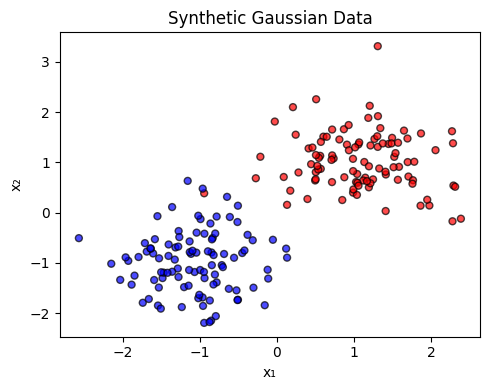

Train: 140  |  Test: 60


In [7]:
# ── DATA SETTINGS ──────────────────────────────────────────────────────────────
N_SAMPLES    = 200    # total data points
NOISE        = 0.6    # cluster spread (try 0.2 → 1.5)
TRAIN_RATIO  = 0.70   # fraction used for training
# ───────────────────────────────────────────────────────────────────────────────

X, y = make_blobs(n_samples=N_SAMPLES, centers=[[-1,-1],[1,1]],
                  cluster_std=NOISE, random_state=42)
X = StandardScaler().fit_transform(X)  # normalize inputs

# Train / test split
split = int(N_SAMPLES * TRAIN_RATIO)
idx   = np.random.permutation(N_SAMPLES)
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

# Convert to PyTorch tensors
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # shape [N,1]
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

# Quick plot
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', s=25, alpha=0.7)
plt.title('Synthetic Gaussian Data')
plt.xlabel('x₁'); plt.ylabel('x₂')
plt.tight_layout(); plt.show()
print(f'Train: {len(X_tr)}  |  Test: {len(X_te)}')

---
## 🏗️ Step 2 — Build the Network

**This is the main cell to experiment with.**

| Variable | What it controls |
|---|---|
| `HIDDEN_LAYERS` | list of neuron counts per hidden layer |
| `ACTIVATION` | `'sigmoid'`, `'relu'`, `'tanh'` |
| `LEARNING_RATE` | step size for gradient descent |
| `EPOCHS` | training iterations |

**Try these presets:**
- `[]` → no hidden layers (logistic regression!)
- `[4]` → 1 layer, 4 neurons
- `[4, 2]` → 2 layers
- `[8, 4, 2]` → 3 layers

In [ ]:
# ── NETWORK SETTINGS ───────────────────────────────────────────────────────────
HIDDEN_LAYERS = [4, 2]     # e.g. [4], [4,2], [8,4,2], or [] for logistic regression
ACTIVATION    = 'sigmoid'  # 'sigmoid' | 'relu' | 'tanh'
LEARNING_RATE = 0.03
EPOCHS        = 1000
# ───────────────────────────────────────────────────────────────────────────────

ACT_MAP = {'sigmoid': nn.Sigmoid(), 'relu': nn.ReLU(), 'tanh': nn.Tanh()}

def build_network(hidden_layers, activation):
    """Dynamically build a feedforward network."""
    act = ACT_MAP[activation]
    layers = []
    in_features = 2  # our data has 2 input features: x₁, x₂

    for n_neurons in hidden_layers:
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(ACT_MAP[activation])  # activation after each hidden layer
        in_features = n_neurons

    layers.append(nn.Linear(in_features, 1))  # output layer
    layers.append(nn.Sigmoid())               # sigmoid → probability (0 or 1)
    return nn.Sequential(*layers)

model = build_network(HIDDEN_LAYERS, ACTIVATION)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters (weights + biases): {total_params}')

---
## 🏋️ Step 3 — Train

We use **Binary Cross-Entropy loss** and **SGD** (same as the playground's squared error / gradient descent setup).

In [ ]:
criterion = nn.BCELoss()  # binary cross-entropy
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

train_losses, test_losses = [], []

for epoch in range(EPOCHS):
    # ── Forward pass ──
    model.train()
    y_pred = model(X_tr)
    loss   = criterion(y_pred, y_tr)

    # ── Backward pass (compute gradients) ──
    optimizer.zero_grad()  # clear old gradients
    loss.backward()        # compute new gradients
    optimizer.step()       # update weights

    # ── Evaluate on test set ──
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_te), y_te).item()

    train_losses.append(loss.item())
    test_losses.append(test_loss)

    if (epoch + 1) % 200 == 0:
        print(f'Epoch {epoch+1:4d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss:.4f}')

# Final accuracy
with torch.no_grad():
    preds = (model(X_te) >= 0.5).float()
    acc   = (preds == y_te).float().mean().item()
print(f'\n✅ Test Accuracy: {acc*100:.1f}%')

---
## 📊 Step 4 — Visualize

The **decision boundary** is the region where the model is uncertain (output ≈ 0.5).
Blue region → model predicts class 1. Red region → class 0.

In [ ]:
def plot_results(model, X_train, y_train, X_test, y_test, train_losses, test_losses):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: Decision Boundary ──
    ax = axes[0]
    h  = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
    ax.contour(xx, yy,  Z, levels=[0.5], colors='white', linewidths=1.5, linestyles='--')
    # Training data
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr',
               edgecolors='k', s=30, label='Train')
    # Test data (diamonds)
    ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr',
               edgecolors='k', s=50, marker='D', alpha=0.6, label='Test')
    ax.set_title('Decision Boundary')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.legend()

    # ── Right: Loss Curves ──
    ax2 = axes[1]
    ax2.plot(train_losses, label='Train Loss', color='steelblue')
    ax2.plot(test_losses,  label='Test Loss',  color='tomato', linestyle='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.set_title('Training Curve')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_results(model, X_train, y_train, X_test, y_test, train_losses, test_losses)

---
## 🧪 Step 5 — Experiment!

Go back to **Step 2** and try these changes. Re-run Steps 2–4 each time.

| Experiment | Setting | Expected Result |
|---|---|---|
| No hidden layers | `HIDDEN_LAYERS = []` | Straight-line boundary (logistic regression) |
| More neurons | `[16, 8]` | More expressive, may overfit |
| ReLU activation | `ACTIVATION = 'relu'` | Sharper, piecewise-linear boundary |
| High learning rate | `LEARNING_RATE = 0.5` | Unstable loss curve |
| More noise | Change `NOISE = 1.5` in Step 1 | Harder classification, boundary less clean |
| Deep network | `[8, 8, 8, 4]` | Can it still learn? |

---
## 🔑 Key PyTorch Concepts

```python
nn.Linear(in, out)   # a fully-connected layer: out = W·x + b
nn.Sequential(...)   # stacks layers in order
loss.backward()      # autograd: computes all gradients automatically
optimizer.step()     # updates every weight by -lr × gradient
torch.no_grad()      # inference mode: skip gradient computation
```

The three-line training loop is the heart of all PyTorch models:
```python
optimizer.zero_grad()  # 1. clear
loss.backward()        # 2. compute
optimizer.step()       # 3. update
```